<a href="https://colab.research.google.com/github/rayalanigama-crypto/Nascomlab-CSEB/blob/main/prob_and_statis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()
print(df.dtypes)
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

Loaded tips dataset: (244, 7)
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print("Loaded tips dataset:", df.shape)
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print("Numerical columns:", numerical)
print("Categorical columns:", categorical)
print("Mean tip:", round(df['tip'].mean(), 2))
print("Sex value counts:")
print(df['sex'].value_counts())

Loaded tips dataset: (244, 7)
Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']
Mean tip: 3.0
Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


In [9]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


In [ ]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())
print(df["tip"].mean())
print(df["sex"].value_counts)

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
2.99827868852459
<bound method IndexOpsMixin.value_counts of 0      Female
1        Male
2        Male
3        Male
4      Female
        ...  
239      Male
240    Female
241      Male
242      Male
243    Female
Name: sex, Length: 244, dtype: category
Categories (2, object): ['Male', 'Female']>


In [ ]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


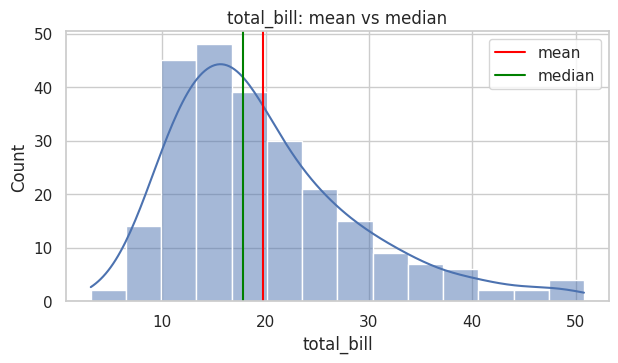

In [ ]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean   : 3.0
Median : 2.9
Mode   : 2.0
mean > median ? True -> right-skewed


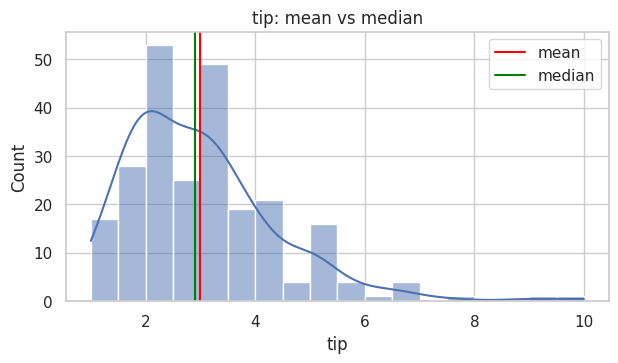

In [11]:
tip = df['tip']
print('Mean   :', round(tip.mean(), 2))
print('Median :', round(tip.median(), 2))
print('Mode   :', round(tip.mode()[0], 2))
print('mean > median ?', tip.mean() > tip.median(), '-> right-skewed')
plt.figure(figsize=(7, 3.5))
sns.histplot(tip, kde=True)
plt.axvline(tip.mean(), color='red', label='mean')
plt.axvline(tip.median(), color='green', label='median')
plt.legend()
plt.title('tip: mean vs median')
plt.show()

In [ ]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [ ]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2))

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78


In [12]:
tip = df['tip']
print('Range    :', round(tip.max() - tip.min(), 2))
print('Variance :', round(tip.var(), 2))
print('Std      :', round(tip.std(), 2))
# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1
print('Q1  :', round(Q1, 2))
print('Q3  :', round(Q3, 2))
print('IQR :', round(IQR, 2))


# 3. Most robust measure of spread = ?
# IQR (Interquartile Range)

Range    : 9.0
Variance : 1.91
Std      : 1.38
Q1  : 2.0
Q3  : 3.56
IQR : 1.56


In [ ]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


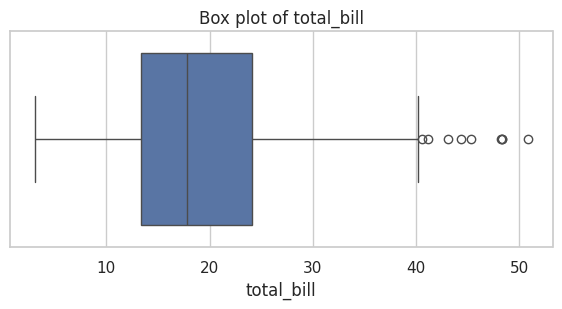

In [ ]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

In [ ]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2))

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


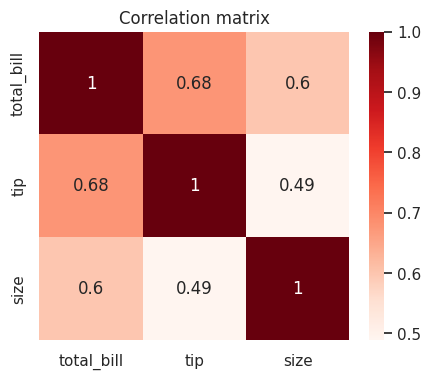

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Reds')
plt.title('Correlation matrix'); plt.show()
df.describe()